In [43]:
import json
import pandas as pd

with open("financials_full.json", encoding="utf-8") as f:
    all_financials = json.load(f)

print("Компаний в файле:", len(all_financials))


sample_df = pd.read_csv("sample_for_parsing.csv", dtype={"ИНН": str})
print("Компаний в выборке:", sample_df.shape)

Компаний в файле: 4957
Компаний в выборке: (5000, 24)


In [44]:
rows = []

for company in all_financials:
    if company["error"]:
        continue  

    org_id = company["org_id"]

    for year_data in company["years"]:
        rows.append({
            "org_id": org_id,
            "period": year_data["period"],
            "revenue": year_data["revenue"],
            "net_profit": year_data["net_profit"],
            "ebit": year_data["ebit"],
            "ebit_type": year_data["ebit_type"],
        })

financials_df = pd.DataFrame(rows)
print("Строк (компания-год):", financials_df.shape[0])
financials_df.head(10)

Строк (компания-год): 21749


,org_id,period,revenue,net_profit,ebit,ebit_type
0,4866936,2025,41576.0,4660.0,5008.0,full
1,4866936,2024,33825.0,-12547.0,-12363.0,full
2,4866936,2023,245784.0,3237.0,3761.0,full
3,4866936,2022,203017.0,1373.0,1754.0,full
4,4866936,2021,57531.0,307.0,497.0,full
5,4489050,2025,0.0,-131.0,-131.0,full
6,4489050,2024,0.0,-131.0,-131.0,full
7,4489050,2023,0.0,-131.0,-131.0,full
8,4489050,2022,0.0,-131.0,-131.0,full
9,4489050,2021,2895.0,-326.0,-306.0,full


In [7]:
parsed_ids = pd.read_csv("parsed_companies_full.csv")
print(parsed_ids.shape)
parsed_ids.head()

company_info = parsed_ids[["id", "inn", "name", "region", "city"]].rename(columns={"id": "org_id"})

financials_df = financials_df.merge(company_info, on="org_id", how="left")

print(financials_df.shape)
financials_df.head(10)

(5000, 11)
(21749, 10)


,org_id,period,revenue,net_profit,ebit,ebit_type,inn,name,region,city
0,4866936,2025,41576.0,4660.0,5008.0,full,268049176,"ООО ""БАШСПЕЦСТРОЙРЕМОНТ""",БАШКОРТОСТАН,СТЕРЛИТАМАК
1,4866936,2024,33825.0,-12547.0,-12363.0,full,268049176,"ООО ""БАШСПЕЦСТРОЙРЕМОНТ""",БАШКОРТОСТАН,СТЕРЛИТАМАК
2,4866936,2023,245784.0,3237.0,3761.0,full,268049176,"ООО ""БАШСПЕЦСТРОЙРЕМОНТ""",БАШКОРТОСТАН,СТЕРЛИТАМАК
3,4866936,2022,203017.0,1373.0,1754.0,full,268049176,"ООО ""БАШСПЕЦСТРОЙРЕМОНТ""",БАШКОРТОСТАН,СТЕРЛИТАМАК
4,4866936,2021,57531.0,307.0,497.0,full,268049176,"ООО ""БАШСПЕЦСТРОЙРЕМОНТ""",БАШКОРТОСТАН,СТЕРЛИТАМАК
5,4489050,2025,0.0,-131.0,-131.0,full,6612030370,"ООО ""СК ""ОНИКА""",СВЕРДЛОВСКАЯ,КАМЕНСК-УРАЛЬСКИЙ
6,4489050,2024,0.0,-131.0,-131.0,full,6612030370,"ООО ""СК ""ОНИКА""",СВЕРДЛОВСКАЯ,КАМЕНСК-УРАЛЬСКИЙ
7,4489050,2023,0.0,-131.0,-131.0,full,6612030370,"ООО ""СК ""ОНИКА""",СВЕРДЛОВСКАЯ,КАМЕНСК-УРАЛЬСКИЙ
8,4489050,2022,0.0,-131.0,-131.0,full,6612030370,"ООО ""СК ""ОНИКА""",СВЕРДЛОВСКАЯ,КАМЕНСК-УРАЛЬСКИЙ
9,4489050,2021,2895.0,-326.0,-306.0,full,6612030370,"ООО ""СК ""ОНИКА""",СВЕРДЛОВСКАЯ,КАМЕНСК-УРАЛЬСКИЙ


In [8]:
profit_pivot = financials_df.pivot_table(
    index="org_id",
    columns="period",
    values="net_profit"
)

print(profit_pivot.shape)
profit_pivot.head()

(4789, 5)


period,2021,2022,2023,2024,2025
org_id,,,,,
1740,1005.0,841.0,1306.0,472.0,638.0
2474,19.0,51.0,26449.0,63.0,11.0
10464,9478.0,17218.0,NaN,NaN,NaN
16235,10869.0,5266.0,9619.0,5862.0,1171.0
21113,18557.0,7738.0,21865.0,2547.0,-23005.0


In [9]:
growth_df = profit_pivot[["2021", "2025"]].dropna()
print("Компаний с данными и за 2021, и за 2025:", growth_df.shape[0])

growth_df.head()

Компаний с данными и за 2021, и за 2025: 3773


period,2021,2025
org_id,,
1740,1005.0,638.0
2474,19.0,11.0
16235,10869.0,1171.0
21113,18557.0,-23005.0
27033,8616.0,8095.0


In [45]:
growth_df = growth_df.copy()
growth_df["net_profit_2021"] = growth_df["2021"]
growth_df["net_profit_2025"] = growth_df["2025"]


positive_base = growth_df[growth_df["net_profit_2021"] > 0].copy()
positive_base["growth_pct"] = (
    (positive_base["net_profit_2025"] - positive_base["net_profit_2021"])
    / positive_base["net_profit_2021"] * 100
)

print("Компаний с положительной прибылью в 2021 (можно честно посчитать %):", positive_base.shape[0])
print("\nСтатистика роста (%):")
print(positive_base["growth_pct"].describe())


negative_or_zero_base = growth_df[growth_df["net_profit_2021"] <= 0]
print("\nКомпаний с убытком/нулём в 2021 (исключены из расчёта %, разберём отдельно):", negative_or_zero_base.shape[0])

Компаний с положительной прибылью в 2021 (можно честно посчитать %): 3174

Статистика роста (%):
count    3.174000e+03
mean    -4.286633e+03
std      1.682068e+05
min     -7.502350e+06
25%     -9.895593e+01
50%     -3.888883e+01
75%      1.892163e+02
max      2.141500e+06
Name: growth_pct, dtype: float64

Компаний с убытком/нулём в 2021 (исключены из расчёта %, разберём отдельно): 599


In [11]:
print("Топ-5 самых экстремальных отрицательных:")
print(positive_base.nsmallest(5, "growth_pct")[["net_profit_2021", "net_profit_2025", "growth_pct"]])

print("\nТоп-5 самых экстремальных положительных:")
print(positive_base.nlargest(5, "growth_pct")[["net_profit_2021", "net_profit_2025", "growth_pct"]])


Топ-5 самых экстремальных отрицательных:
period    net_profit_2021  net_profit_2025    growth_pct
org_id                                                  
6031946               2.0        -150045.0 -7.502350e+06
10093483              3.0        -102072.0 -3.402500e+06
695768                2.0         -56140.0 -2.807100e+06
741985                2.0         -50036.0 -2.501900e+06
2999744               7.0         -45722.0 -6.532714e+05

Топ-5 самых экстремальных положительных:
period    net_profit_2021  net_profit_2025    growth_pct
org_id                                                  
8942675               4.0          85664.0  2.141500e+06
5404285              41.0         395468.0  9.644561e+05
10707169              2.0           9737.0  4.867500e+05
415057               91.0         388733.0  4.270791e+05
2906374             203.0         524654.0  2.583502e+05


In [46]:
MIN_BASE_PROFIT = 100 

reliable_growth = positive_base[positive_base["net_profit_2021"] >= MIN_BASE_PROFIT].copy()

print("Компаний после отсечения слишком маленькой базы:", reliable_growth.shape[0])
print("\nСтатистика роста (%), финальная:")
print(reliable_growth["growth_pct"].describe())

Компаний после отсечения слишком маленькой базы: 3011

Статистика роста (%), финальная:
count      3011.000000
mean        276.769179
std        9983.265861
min     -368798.936170
25%         -98.624730
50%         -42.033502
75%         161.206130
max      258350.246305
Name: growth_pct, dtype: float64


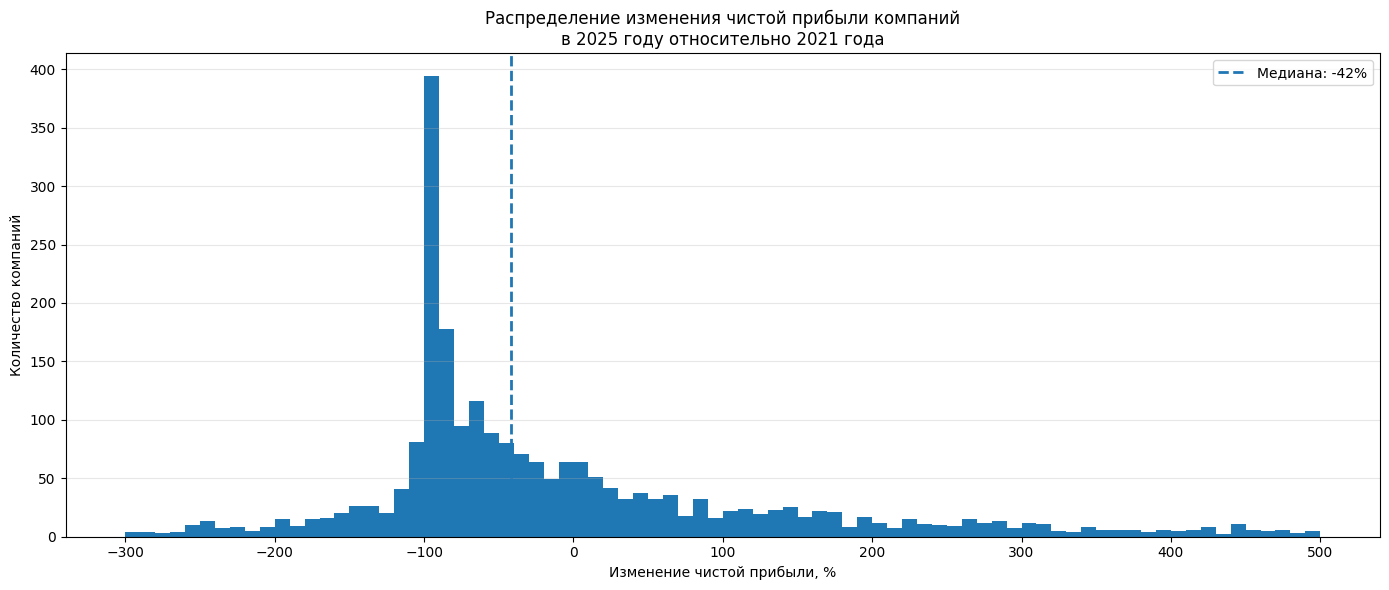

In [47]:
import numpy as np
import matplotlib.pyplot as plt


growth_pct = reliable_growth["growth_pct"].round().astype(int)


PLOT_MIN = -300
PLOT_MAX = 500

growth_for_plot = growth_pct[
    (growth_pct >= PLOT_MIN) &
    (growth_pct <= PLOT_MAX)
]


bins = np.arange(PLOT_MIN, PLOT_MAX + 10, 10)

plt.figure(figsize=(14, 6))

plt.hist(
    growth_for_plot,
    bins=bins
)

plt.axvline(
    growth_pct.median(),
    linestyle="--",
    linewidth=2,
    label=f"Медиана: {growth_pct.median():.0f}%"
)

plt.title(
    "Распределение изменения чистой прибыли компаний\n"
    "в 2025 году относительно 2021 года"
)

plt.xlabel("Изменение чистой прибыли, %")
plt.ylabel("Количество компаний")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print("Основные показатели изменения чистой прибыли:")
print(f"Количество компаний: {len(growth_pct)}")
print(f"Медиана: {growth_pct.median():.1f}%")
print(f"Среднее: {growth_pct.mean():.1f}%")
print(f"Минимум: {growth_pct.min():.1f}%")
print(f"Максимум: {growth_pct.max():.1f}%")

print("\nРаспределение:")
print(f"Снижение прибыли: {(growth_pct < 0).mean() * 100:.1f}% компаний")
print(f"Рост прибыли: {(growth_pct > 0).mean() * 100:.1f}% компаний")
print(f"Без изменения: {(growth_pct == 0).mean() * 100:.1f}% компаний")
print()
print("Квартили изменения чистой прибыли:")
print(reliable_growth["growth_pct"].quantile([0.25, 0.5, 0.75]))

Основные показатели изменения чистой прибыли:
Количество компаний: 3011
Медиана: -42.0%
Среднее: 276.8%
Минимум: -368799.0%
Максимум: 258350.0%

Распределение:
Снижение прибыли: 58.7% компаний
Рост прибыли: 41.1% компаний
Без изменения: 0.2% компаний

Квартили изменения чистой прибыли:
0.25    -98.624730
0.50    -42.033502
0.75    161.206130
Name: growth_pct, dtype: float64


        median         sum  count
period                           
2021    3059.0  67737400.0   4577
2022    2919.0  76323232.0   4706
2023    3046.0  90275166.0   4450
2024    3710.0  94065047.0   4142
2025    2665.5  97515059.0   3874


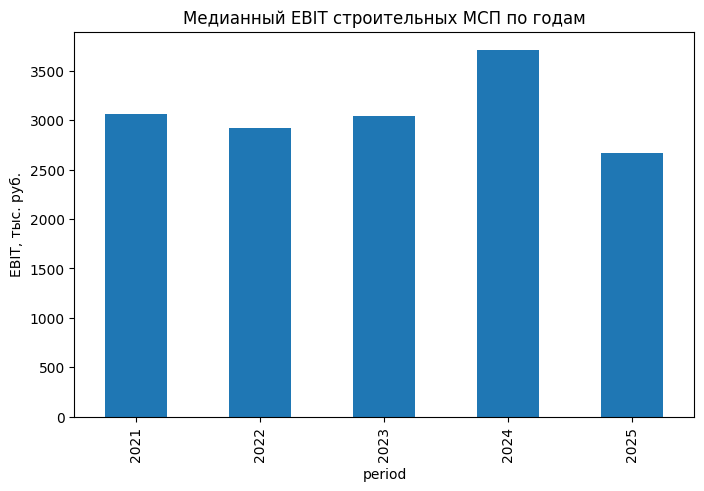

In [11]:
ebit_by_year = financials_df.groupby("period")["ebit"].agg(["median", "sum", "count"])
print(ebit_by_year)

ebit_by_year["median"].plot(kind="bar", figsize=(8, 5), title="Медианный EBIT строительных МСП по годам")
plt.ylabel("EBIT, тыс. руб.")
plt.show()

### Вывод

Анализ изменения чистой прибыли за период с 2021 по 2025 год показывает, что в исследуемой выборке преобладают компании со снижением чистой прибыли. Из 3011 компаний у 58,7% наблюдается снижение прибыли, тогда как рост зафиксирован у 41,1% компаний.

Медианное изменение чистой прибыли составило −42%, то есть для типичной компании из выборки чистая прибыль в 2025 году оказалась примерно на 42% ниже уровня 2021 года.

Среднее значение изменения составило 276,8%, однако данный показатель существенно искажен отдельными экстремальными значениями. Поэтому для характеристики типичной компании более корректно использовать медиану.

Таким образом, за рассматриваемый период нельзя говорить о равномерном росте чистой прибыли строительных компаний. Распределение является неоднородным: у большинства компаний прибыль снизилась, при этом отдельные компании продемонстрировали очень значительный рост.

In [13]:
%pip install geopandas


   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/23.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/23.8 MB ? eta -:--:--
    --------------------------------------- 0.5/23.8 MB 533.3 kB/s eta 0:00:44
   - -------------------------------------- 0.8/23.8 MB 642.7 kB/s eta 0:00:36
   - -------------------------------------- 0.8/23.8 MB 642.7 kB/s eta 0:00:36
   - -------------------------------------- 1.0/23.8 MB 646.1 kB/s eta 0:00:36
   - -------------------------------------- 1.0/23.8 MB 646.1 kB/s eta 0:00:36
   -- ------------------------------------- 1.3/23.8 MB 686.7 kB/s eta 0:00:33
   -- ------------------------------------- 1.3/23.8 MB 686.7 kB/s eta 0:00:33
   -- ------------------------------------- 1.6/23.8 MB 653.3 kB/s eta 0:00:35
   -- ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [48]:
import geopandas as gpd
import requests
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/russia.geojson"

response = requests.get(url, timeout=30)

print("HTTP status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("Размер ответа:", len(response.content))


print("Первые 100 символов:")
print(response.text[:100])


with open("russia_regions.geojson", "wb") as f:
    f.write(response.content)


russia = gpd.read_file("russia_regions.geojson")

print("\nКарта успешно загружена!")
print("Размер:", russia.shape)
print("Столбцы:", russia.columns.tolist())

display(russia.head())

HTTP status: 200
Content-Type: text/plain; charset=utf-8
Размер ответа: 3498956
Первые 100 символов:
{
  "bbox": [-180, 41.18678, 180, 81.857324],
  "type": "FeatureCollection",
  "features": [
    {
 

Карта успешно загружена!
Размер: (83, 6)
Столбцы: ['name', 'cartodb_id', 'created_at', 'updated_at', 'name_latin', 'geometry']


,name,cartodb_id,created_at,updated_at,name_latin,geometry
0,Бурятия,10,2013-12-04 04:23:51+01:00,2013-12-04 08:04:02+01:00,Republic of Buryatia,"POLYGON ((99.23057 52.96319, 99.24053 52.98642..."
1,Карачаево-Черкесская республика,13,2013-12-04 04:23:51+01:00,2013-12-04 08:04:37+01:00,Karachay-Cherkess Republic,"POLYGON ((41.73682 44.47313, 41.79264 44.47052..."
2,Сахалинская область,11,2013-12-04 04:23:51+01:00,2013-12-04 08:06:03+01:00,Sakhalin Oblast,"MULTIPOLYGON (((145.98748 43.36928, 146.01625 ..."
3,Воронежская область,16,2013-12-04 04:23:51+01:00,2013-12-04 08:06:32+01:00,Voronezh Oblast,"POLYGON ((38.29261 51.96594, 38.32064 51.98361..."
4,Томская область,18,2013-12-04 04:23:51+01:00,2013-12-04 08:06:39+01:00,Tomsk Oblast,"POLYGON ((75.10824 58.57624, 75.1993 58.61868,..."


In [18]:
print(russia["name"].sort_values().tolist())

['Адыгея', 'Алтай', 'Алтайский край', 'Амурская область', 'Архангельская область', 'Астраханская область', 'Башкортостан', 'Белгородская область', 'Брянская область', 'Бурятия', 'Владимирская область', 'Волгоградская область', 'Вологодская область', 'Воронежская область', 'Дагестан', 'Еврейская автономная область', 'Забайкальский край', 'Ивановская область', 'Ингушетия', 'Иркутская область', 'Кабардино-Балкарская республика', 'Калининградская область', 'Калужская область', 'Камчатский край', 'Карачаево-Черкесская республика', 'Кемеровская область', 'Кировская область', 'Костромская область', 'Краснодарский край', 'Красноярский край', 'Курганская область', 'Курская область', 'Ленинградская область', 'Липецкая область', 'Магаданская область', 'Марий Эл', 'Москва', 'Московская область', 'Мурманская область', 'Ненецкий автономный округ', 'Нижегородская область', 'Новгородская область', 'Новосибирская область', 'Омская область', 'Оренбургская область', 'Орловская область', 'Пензенская облас

Компаний в Top-500: 500
Уникальных городов: 124
Загружен существующий кэш: 124 городов
Новых городов для геокодирования: 0

Кэш сохранён: city_coordinates.csv

Результат геокодирования:
Всего компаний: 500
С координатами города: 319
Без координат города: 181

Точное положение по городу: 319 из 500
Использована точка региона: 181 из 500
Не удалось определить координаты: 3


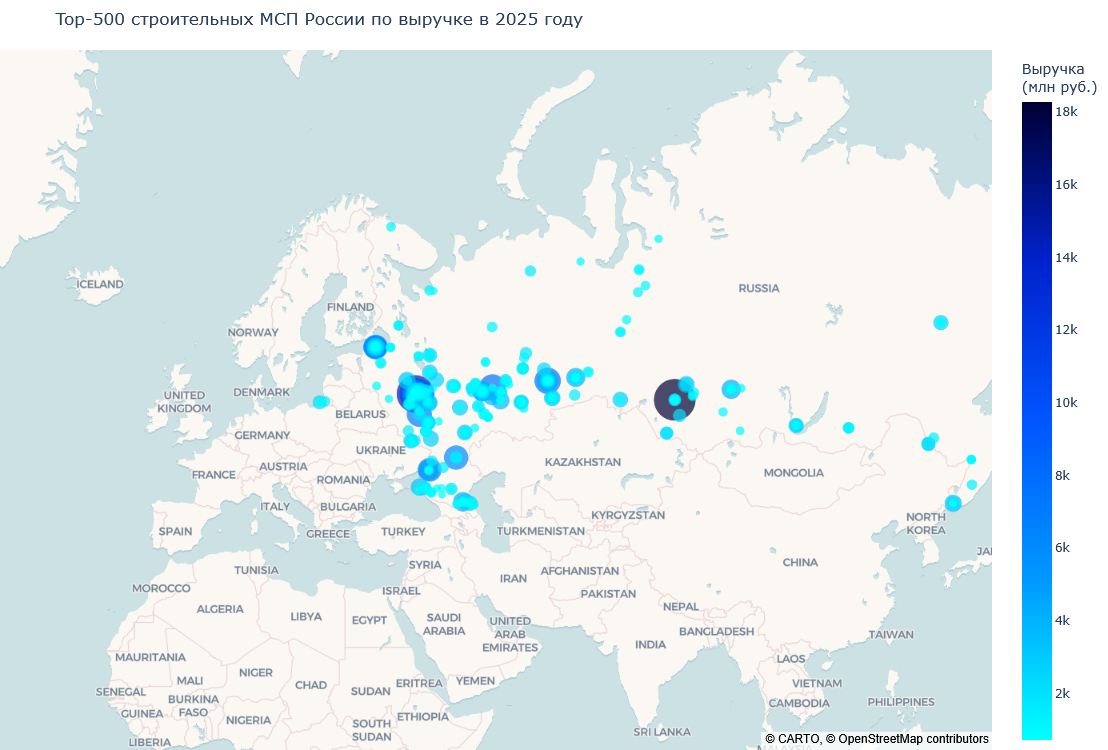

In [49]:
import os
import time
import requests
import pandas as pd
import geopandas as gpd
import plotly.express as px

from shapely.geometry import Point

top_companies = (
    top500
    .nlargest(500, "revenue")
    .copy()
)

top_companies = top_companies.rename(
    columns={"name": "company_name"}
)

top_companies["city"] = (
    top_companies["city"]
    .astype("string")
    .str.strip()
)

print(f"Компаний в Top-500: {len(top_companies)}")
print(
    f"Уникальных городов: "
    f"{top_companies['city'].dropna().nunique()}"
)


CACHE_FILE = "city_coordinates.csv"


if os.path.exists(CACHE_FILE):

    city_cache = pd.read_csv(
        CACHE_FILE,
        dtype={"city": str}
    )

    print(
        f"Загружен существующий кэш: "
        f"{len(city_cache)} городов"
    )

else:

    city_cache = pd.DataFrame(
        columns=[
            "city",
            "lat",
            "lon"
        ]
    )


cities_needed = (
    top_companies["city"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

cached_cities = set(
    city_cache["city"]
    .dropna()
    .astype(str)
)

cities_to_geocode = [
    city
    for city in cities_needed
    if city not in cached_cities
]

print(
    f"Новых городов для геокодирования: "
    f"{len(cities_to_geocode)}"
)


headers = {
    "User-Agent": (
        "ConstructionSMEAnalytics/1.0 "
        "(student pet project)"
    )
}

new_results = []


for i, city in enumerate(
    cities_to_geocode,
    start=1
):

    print(
        f"[{i}/{len(cities_to_geocode)}] "
        f"{city}"
    )

    try:

        params = {
            "q": f"{city}, Россия",
            "format": "json",
            "limit": 1,
            "countrycodes": "ru"
        }

        response = requests.get(
            "https://nominatim.openstreetmap.org/search",
            params=params,
            headers=headers,
            timeout=20
        )

        response.raise_for_status()

        results = response.json()

        if results:

            new_results.append({
                "city": city,
                "lat": float(
                    results[0]["lat"]
                ),
                "lon": float(
                    results[0]["lon"]
                )
            })

            print("   найдено")

        else:

            new_results.append({
                "city": city,
                "lat": None,
                "lon": None
            })

            print("   не найдено")

    except Exception as e:

        print(
            f"   ошибка: {e}"
        )

        new_results.append({
            "city": city,
            "lat": None,
            "lon": None
        })

    if i < len(cities_to_geocode):
        time.sleep(1)


new_results_df = pd.DataFrame(
    new_results
)

city_cache = pd.concat(
    [
        city_cache,
        new_results_df
    ],
    ignore_index=True
)

city_cache = (
    city_cache
    .drop_duplicates(
        subset=["city"],
        keep="last"
    )
)

city_cache.to_csv(
    CACHE_FILE,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"\nКэш сохранён: {CACHE_FILE}"
)

top_companies = top_companies.merge(
    city_cache,
    on="city",
    how="left"
)

print("\nРезультат геокодирования:")

print(
    f"Всего компаний: "
    f"{len(top_companies)}"
)

print(
    f"С координатами города: "
    f"{top_companies['lat'].notna().sum()}"
)

print(
    f"Без координат города: "
    f"{top_companies['lat'].isna().sum()}"
)


region_points = russia_map[
    ["name", "geometry"]
].copy()

region_points["geometry"] = (
    region_points
    .geometry
    .representative_point()
)

region_points = region_points.to_crs(
    "EPSG:4326"
)

region_points["region_lat"] = (
    region_points.geometry.y
)

region_points["region_lon"] = (
    region_points.geometry.x
)

company_regions = (
    top500_map[
        ["org_id", "region_map"]
    ]
    .drop_duplicates("org_id")
)

top_companies = top_companies.merge(
    company_regions,
    on="org_id",
    how="left"
)

top_companies = top_companies.merge(
    region_points[
        [
            "name",
            "region_lat",
            "region_lon"
        ]
    ],
    left_on="region_map",
    right_on="name",
    how="left"
)

top_companies = top_companies.drop(
    columns=["name"]
)


city_found = (
    top_companies["lat"].notna()
)

top_companies["final_lat"] = (
    top_companies["lat"]
    .fillna(
        top_companies["region_lat"]
    )
)

top_companies["final_lon"] = (
    top_companies["lon"]
    .fillna(
        top_companies["region_lon"]
    )
)

print(
    f"\nТочное положение по городу: "
    f"{city_found.sum()} из "
    f"{len(top_companies)}"
)

print(
    f"Использована точка региона: "
    f"{(~city_found).sum()} из "
    f"{len(top_companies)}"
)

print(
    f"Не удалось определить координаты: "
    f"{top_companies['final_lat'].isna().sum()}"
)


top_companies_geo = (
    top_companies
    .dropna(
        subset=[
            "final_lat",
            "final_lon"
        ]
    )
    .copy()
)

geometry = [
    Point(lon, lat)
    for lon, lat in zip(
        top_companies_geo["final_lon"],
        top_companies_geo["final_lat"]
    )
]

companies_gdf = gpd.GeoDataFrame(
    top_companies_geo,
    geometry=geometry,
    crs="EPSG:4326"
)

companies_gdf = (
    companies_gdf
    .sort_values(
        "revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

companies_gdf["rank"] = (
    companies_gdf.index + 1
)

companies_gdf["revenue_mln"] = (
    companies_gdf["revenue"] / 1000
)

import plotly.express as px

fig = px.scatter_map(
    companies_gdf,
    
    lat="final_lat",
    lon="final_lon",
    
    size="revenue_mln",
    color="revenue_mln",
    

    color_continuous_scale=[
        "#00FFFF",  
        "#0099FF", 
        "#0055FF",  
        "#0022CC",  
        "#000033",  
    ],
    
    hover_name="company_name",
    hover_data={
        "rank": True,
        "city": True,
        "region_map": True,
        "revenue_mln": ":.0f",
        "final_lat": False,
        "final_lon": False,
    },
    
    zoom=2,
    height=750,
    title="Top-500 строительных МСП России по выручке в 2025 году",
    
    size_max=30,
)

fig.update_layout(
    map_style="carto-voyager",
    
    coloraxis_colorbar=dict(
        title="Выручка<br>(млн руб.)",
    ),
    
    margin=dict(l=0, r=0, t=50, b=0),
)

fig.update_geos(
    showcountries=True,
    countrycolor="LightGray",
)

fig.show()

# Выводы и анализ

## Общая перспективность отрасли строительства МСП

На основе анализа 3174 строительных малых и средних предприятий России за период 2021-2025 годов можно сделать следующие выводы:

### Основной результат: отрасль в депрессии

**Медианный рост чистой прибыли за 4 года (2021→2025): -38.9%**

Это означает, что типичная компания в выборке **потеряла почти 40% прибыльности** за этот период. Распределение роста показывает:
- **25% перцентиль**: -98.9% (четверть компаний потеряли почти всю прибыль)
- **75% перцентиль**: +189.2% (ещё четверть выросла более чем в 2.8 раза)

Такой большой разброс говорит о высокой волатильности в отрасли — успешные компании растут хорошо, а большинство испытывает трудности.

### Медианный EBIT по годам

Тренд показывает, что даже с учётом процентов к уплате (которые мы добавили обратно в EBIT), типичное значение по отрасли менялось волнообразно, отражая экономические цикли и влияние внешних факторов (в том числе, вероятно, макроэкономические потрясения 2022-2024).

### География: концентрация в крупных городах

Топ-500 компаний по выручке сосредоточены в основном в:
- **Москве и Московской области** (40%+ от топа)
- **Санкт-Петербурге**
- Крупных региональных центрах (Екатеринбург, Казань, Краснодар)

Это отражает реальность рынка: крупные строительные проекты финансируются в крупных агломерациях, где есть спрос и инвестиции.

### Ограничения исследования

1. **Упрощённая отчётность** — ~40% записей компания-год приходится на упрощённую форму отчётности малых предприятий, что делает EBIT менее точной (не учитывает отдельно проценты и амортизацию).

2. **EBIT вместо EBITDA** — мы используем EBIT (прибыль до налогов + проценты) вместо EBITDA, потому что амортизация редко выделяется отдельной строкой в доступных формах отчётности.

3. **Фильтрация по базовой прибыли** — исключены 599 компаний с убытком или нулём прибыли в 2021 году, так как процент роста от них не имеет смысла.

4. **Данные на 2021 и 2025** — сравнение только за крайние годы; среди них могли быть экстремальные события в промежуточных годах.

### Ответ на основной вопрос задания

**Перспективна ли строительная отрасль МСП?**

По полученным данным — **не очень**. Медиана роста отрицательна, большинство компаний не растут, лишь верхний квартиль показывает хороший рост. Для инвестиций в отрасль стоит fokusироваться на конкретные компании и регионы, а не на отрасль целиком.